# Premier Card — EDA
Imports the reusable `PremierEDA` class + `add_features` from `src/eda.py`.
First load reads the xlsx (~28s) then pickle-caches; reruns are instant.

In [1]:
import sys, pathlib
p = pathlib.Path.cwd()
src = next((d / 'src' for d in [p, *p.parents] if (d / 'src' / 'eda.py').exists()), None)
sys.path.insert(0, str(src))
import pandas as pd
pd.set_option('display.width', 200, 'display.max_columns', 30)
%matplotlib inline
from eda import PremierEDA, add_features
eda = PremierEDA()
eda.df.shape

(500000, 24)

In [2]:
eda.legend()    # f-code -> readable variable name -> description (run this first)
# tip: eda.renamed().head()  gives the data with readable column names

,variable,description
code,,
f1,revolve_bal,Avg Revolve Balance 12m
f2,cancel_calls,Cancellation Calls 12m
f3,collect_calls,Collection Cancel Calls
f4,rewards_bal,Rewards Points Balance
f5,total_spend,Total Spend 12m
f6,air_spend,Airlines Spend
f7,other_spend,Other Spend (refunds<0)
f8,ent_spend,Entertainment Spend
f9,lodge_spend,Lodging Spend


## 1. Overview — per-feature stats

In [3]:
eda.overview()

,code,name,missing%,min,max,mean,median,skew,nonzero%
variable,,,,,,,,,
revolve_bal,f1,Avg Revolve Balance 12m,0.0,0.00,17967.73,2467.31,0.00,2.23,46.8
cancel_calls,f2,Cancellation Calls 12m,0.0,0.00,1.00,0.17,0.00,1.72,17.4
collect_calls,f3,Collection Cancel Calls,0.0,0.00,1.00,0.11,0.00,2.52,10.9
rewards_bal,f4,Rewards Points Balance,51.4,2.00,697899.35,126607.13,50705.19,1.97,100.0
total_spend,f5,Total Spend 12m,1.3,0.00,13596.28,3464.81,2165.85,1.37,93.5
air_spend,f6,Airlines Spend,23.1,0.00,52198.43,10032.05,4022.77,1.83,85.4
other_spend,f7,Other Spend (refunds<0),23.1,-274.65,146700.55,30821.55,14396.27,1.69,99.8
ent_spend,f8,Entertainment Spend,23.1,0.00,9419.87,1522.99,303.99,2.03,68.8
lodge_spend,f9,Lodging Spend,23.1,0.00,10828.99,1651.74,264.75,2.13,63.5


## 2. Missingness — structured co-missing clusters (treat as signal, not impute)

In [4]:
eda.missingness()

,cluster,missing%,interpretation
0,f23,87.8,Emails Clicked 6m
1,f18,61.9,Consumer Lend Line
2,f17,58.5,Total Lend Line
3,"f4, f21",51.4,"Rewards Points Balance, Rewards Redeemed 12m"
4,"f6, f7, f8, f9, f10",23.1,"Airlines Spend, Other Spend (refunds<0), Enter..."
5,f22,18.9,Emails Opened 6m
6,f12,5.0,Website Logins
7,"f13, f14, f15, f16",2.7,"Lounge Access Count, Airline Credits Used, Cab..."
8,f5,1.3,Total Spend 12m
9,f11,0.5,Avg Risk Score (PD-like)


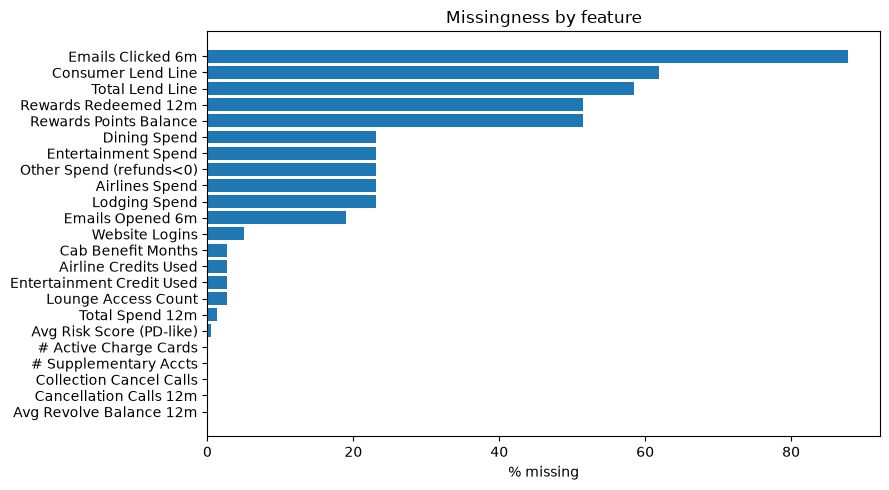

In [5]:
eda.plot_missingness();

## 3. Correlations — collinearity (motivates CRITIC-style weighting)

In [6]:
eda.correlations()

,var_a,var_b,a,b,r
0,lend_line,consumer_lend,f17,f18,0.90
1,air_spend,lodge_spend,f6,f9,0.70
2,other_spend,dine_spend,f7,f10,0.66
3,ent_spend,dine_spend,f8,f10,0.62


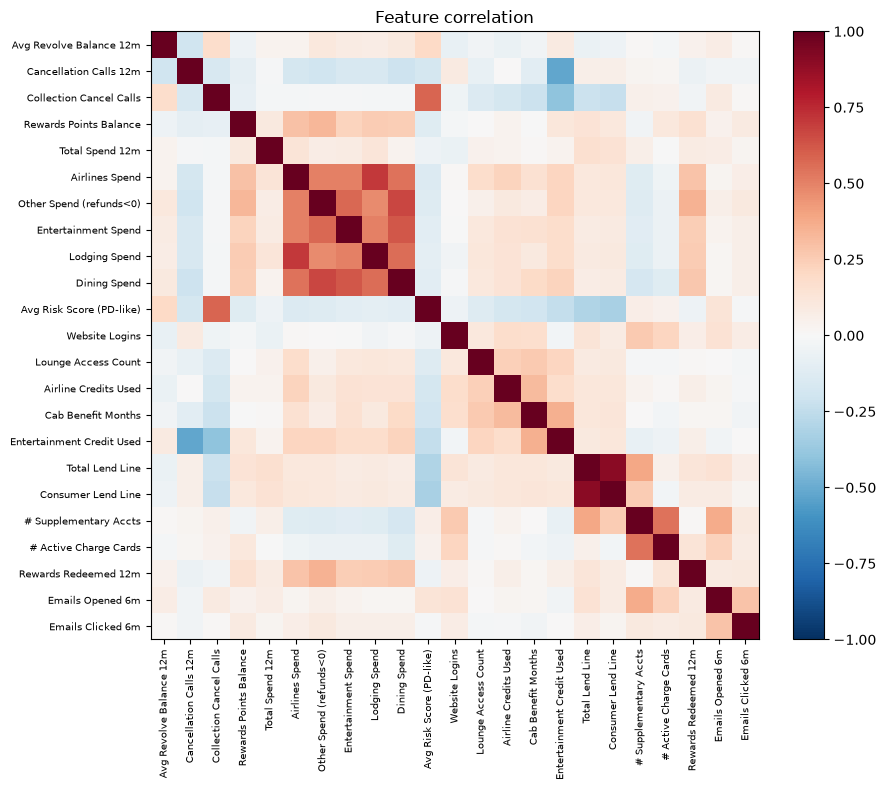

In [7]:
eda.plot_corr();

## 4. Distributions — heavy tails (log1p) -> rank/log-transform before combining

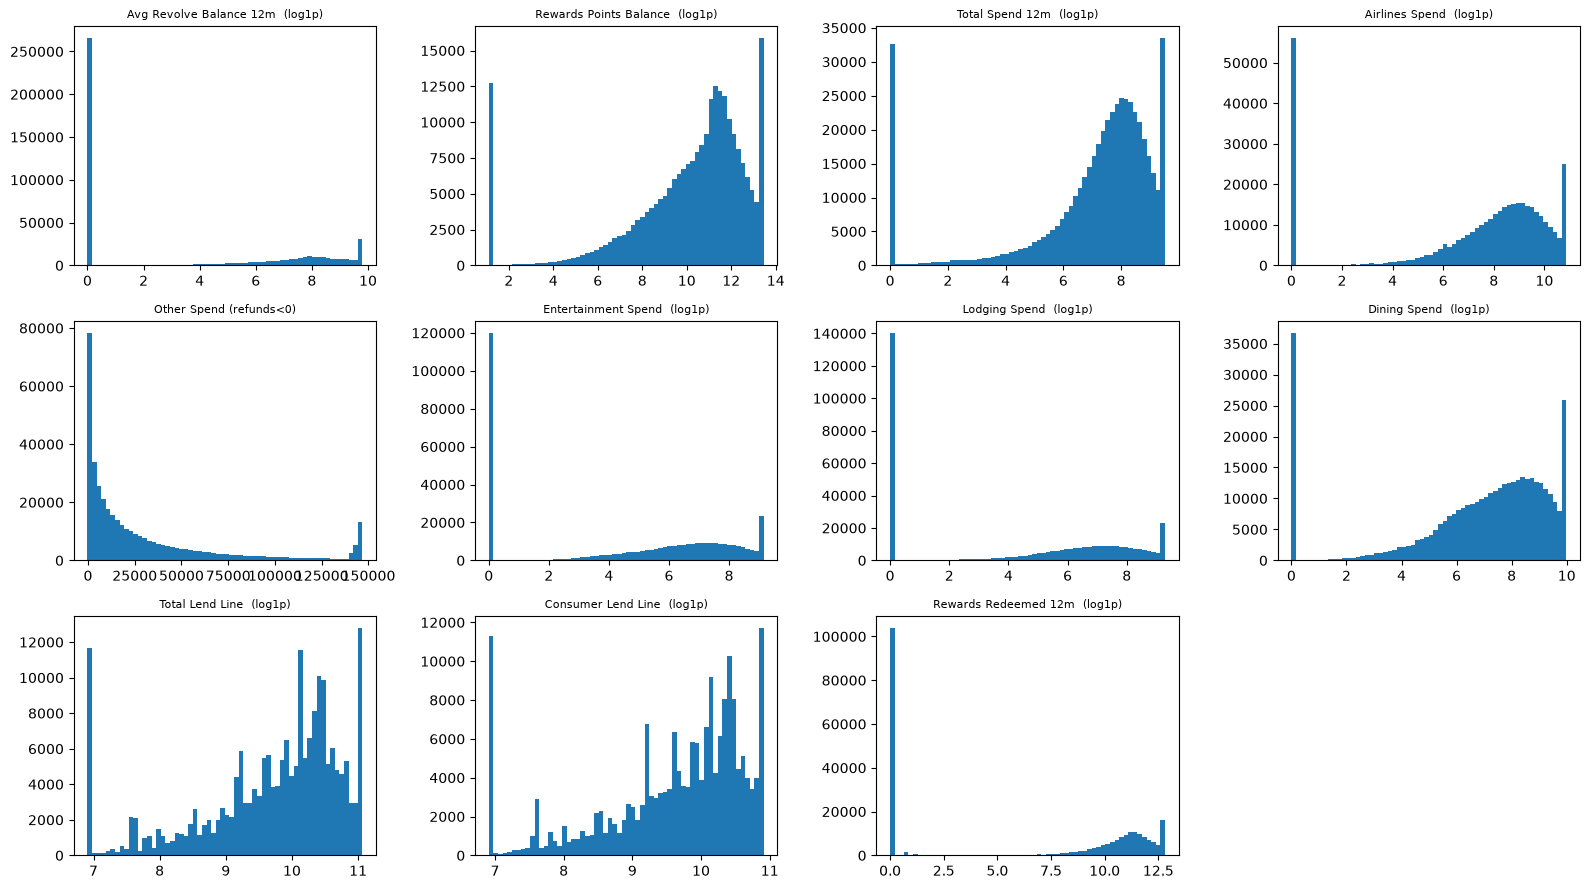

In [8]:
eda.plot_distributions();

## 5. Segments — transactor / revolver / lender archetypes

In [9]:
eda.segments()

,n,share%,total_spend,revolve_bal,risk_score,rewards_bal,cancel_calls
lender (has lend line),207746,41.5,3700.0,2618.0,0.0396,107592.0,0.187
transactor (charge-only),159584,31.9,3486.0,0.0,0.0056,164394.0,0.236
revolver (no lend line),132670,26.5,3065.0,5198.0,0.0591,109548.0,0.080


## 6. Top-20% tail — the only region the metric scores. (try by='f7' too — the big-volume category)

In [10]:
eda.top_tail('f5')

,code,top20%_by_total_spend,rest,ratio
variable,,,,
revolve_bal,f1,2613.79,2440.63,1.07
cancel_calls,f2,0.17,0.18,0.93
collect_calls,f3,0.09,0.11,0.75
rewards_bal,f4,155790.06,116538.22,1.34
total_spend,f5,9825.08,1874.75,5.24
air_spend,f6,13317.68,9144.63,1.46
other_spend,f7,37041.65,29143.19,1.27
ent_spend,f8,1903.33,1420.45,1.34
lodge_spend,f9,2279.75,1484.56,1.54


In [11]:
eda.top_tail('f7')

,code,top20%_by_other_spend,rest,ratio
variable,,,,
revolve_bal,f1,3202.32,2145.29,1.49
cancel_calls,f2,0.03,0.16,0.17
collect_calls,f3,0.00,0.00,0.53
rewards_bal,f4,223430.62,102353.15,2.18
total_spend,f5,4041.97,3402.44,1.19
air_spend,f6,22174.36,6996.44,3.17
other_spend,f7,99223.98,13720.77,7.23
ent_spend,f8,3994.76,905.04,4.41
lodge_spend,f9,3998.03,1065.16,3.75


## 7. Derived features (from f1–f23 only) — flags, ratios, rank transforms

In [12]:
feats = add_features(eda.df)
new = [c for c in feats.columns if c not in eda.df.columns]
feats[new].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
has_lend_line,500000.0,0.415,0.493,0.000,0.000,0.000,1.000,1.000
is_rewards_member,500000.0,0.486,0.500,0.000,0.000,0.000,1.000,1.000
has_spend_breakdown,500000.0,0.769,0.422,0.000,1.000,1.000,1.000,1.000
is_revolver,500000.0,0.681,0.466,0.000,0.000,1.000,1.000,1.000
redemption_intensity,242772.0,0.355,0.385,0.000,0.000,0.192,0.747,1.000
benefit_burden,480291.0,7.050,31.430,0.001,0.014,0.037,0.137,278.403
spend_diversity,500000.0,3.090,2.010,0.000,1.000,4.000,5.000,5.000
engagement,474994.0,13.989,13.928,0.000,4.000,9.000,19.000,58.000
revolve_to_lend,207746.0,0.444,1.608,0.000,0.000,0.000,0.209,17.968
net_spend,384302.0,48564.702,55945.419,-274.646,8618.521,26964.293,66771.818,240798.436
